<a href="https://colab.research.google.com/github/Keshusrm/DeepLearning/blob/main/Lab3(DL).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [ ]:
n_samples_per_class = 100
X_class0 = np.random.randn(n_samples_per_class, 2) + np.array([2, 2])
X_class1 = np.random.randn(n_samples_per_class, 2) + np.array([5, 5])
X = np.vstack((X_class0, X_class1))
y = np.hstack((
    np.zeros(n_samples_per_class),
    np.ones(n_samples_per_class)
))
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class 0 samples:", np.sum(y == 0))
print("Class 1 samples:", np.sum(y == 1))

X shape: (200, 2)
y shape: (200,)
Class 0 samples: 100
Class 1 samples: 100


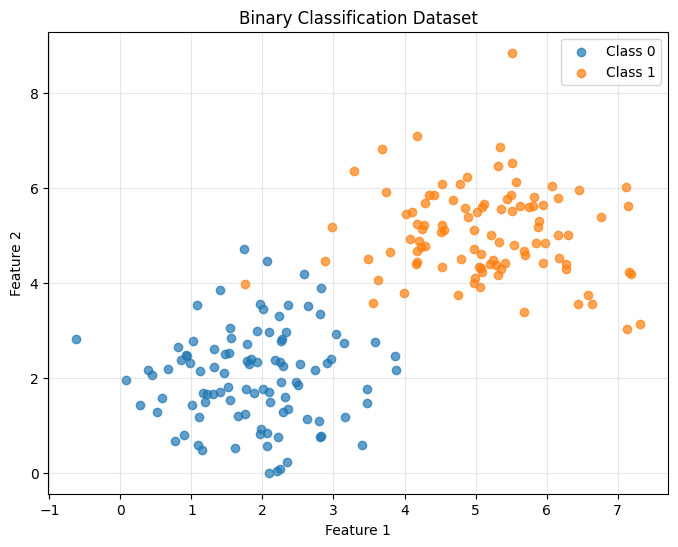

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    label="Class 0",
    alpha=0.7
)

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label="Class 1",
    alpha=0.7
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Binary Classification Dataset")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Shuffle the dataset
indices = np.random.permutation(len(X))

X = X[indices]
y = y[indices]

# 80-20 split
split_index = int(0.8 * len(X))

X_train = X[:split_index]
y_train = y[:split_index]

X_test = X[split_index:]
y_test = y[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 160
Testing samples: 40


In [ ]:
mean=X_train.mean(axis=0)
std=X_train.std(axis=0)
X_train_scaled=(X_train - mean)/std
X_test_scaled=(X_test - mean)/std
print("Training Feature Mean: ",X_train_scaled.mean(axis=0))
print("Training Feature std: ",X_train_scaled.std(axis=0))

Training Feature Mean:  [ 4.26048086e-16 -1.82492910e-16]
Training Feature std:  [1. 1.]


In [ ]:
def sigmoid(z):
  return 1/(1+np.exp(-z))

In [ ]:
test_values=np.array([-5, -1, 0, 1, 5])
print("Output:",sigmoid(test_values))

Output: [0.00669285 0.26894142 0.5        0.73105858 0.99330715]


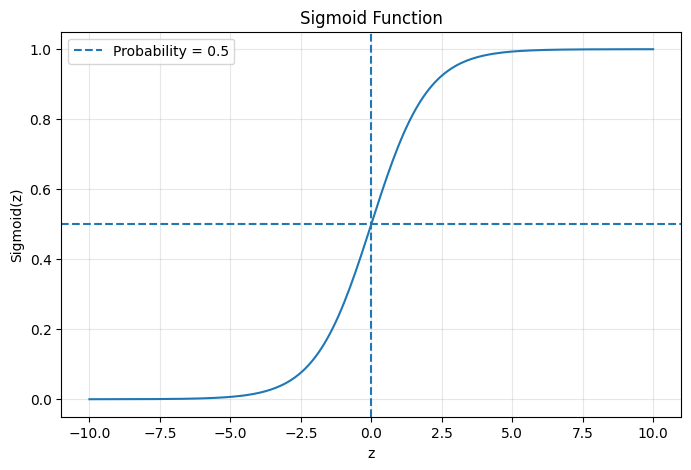

In [ ]:
z_values = np.linspace(-10, 10, 200)
sigmoid_values = sigmoid(z_values)

plt.figure(figsize=(8, 5))
plt.plot(z_values, sigmoid_values)
plt.axhline(0.5, linestyle="--", label="Probability = 0.5")
plt.axvline(0, linestyle="--")
plt.xlabel("z")
plt.ylabel("Sigmoid(z)")
plt.title("Sigmoid Function")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
def binary_cross_entropy(y_true, y_pred):
    # Avoid log(0)
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    loss = -np.mean(
        y_true * np.log(y_pred)+(1 - y_true) * np.log(1 - y_pred)
    )
    return loss

In [ ]:
n_features = X_train_scaled.shape[1]
w = np.zeros(n_features)
b = 0.0
print("Initial weights:", w)
print("Initial bias:", b)

Initial weights: [0. 0.]
Initial bias: 0.0


In [ ]:
def predict_probability(X, w, b):
    z = np.dot(X, w) + b
    return sigmoid(z)

In [ ]:
def compute_gradients(X, y, y_pred):
    m = len(y)
    error = y_pred - y
    dw = (1 / m) * np.dot(X.T, error)
    db = (1 / m) * np.sum(error)
    return dw, db

# 1. First, calculate the initial predictions using your initial weights and bias
initial_predictions = predict_probability(X_train_scaled, w, b)

# 2. Then, pass the predictions as the third argument (y_pred)
dw, db = compute_gradients(
    X_train_scaled,
    y_train,
    initial_predictions
)

In [ ]:
def train_logistic_regression(X, y, learning_rate=0.1, epochs=1000):
    n_samples, n_features = X.shape

    w = np.zeros(n_features)
    b = 0.0

    loss_history = []

    for epoch in range(epochs):
        z = np.dot(X, w) + b
        y_pred = sigmoid(z)

        loss = binary_cross_entropy(y, y_pred)
        loss_history.append(loss)

        dw, db = compute_gradients(X, y, y_pred)

        w = w - learning_rate * dw
        b = b - learning_rate * db

        if epoch % 10 == 0:
            print(f"Epoch {epoch:4d} | Loss: {loss:.6f}")

    return w, b, loss_history

In [ ]:
learning_rate=0.1
epochs=1000
w,b, loss_history=train_logistic_regression(
    X_train_scaled
)